In [63]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    accuracy_score,           # subset accuracy = exact set match
    jaccard_score,
    multilabel_confusion_matrix,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import re
from math import isclose
import matplotlib.pyplot as plt

import json
import numpy as np
from pathlib import Path
import os

from tqdm import tqdm
import difflib
from sklearn.metrics import precision_score, recall_score, f1_score
tqdm.pandas()

In [64]:
ms_hermes = pd.read_csv("./data/ms_berger_sr/HERMES_INCLUDED_PMIDs_valid_title_annotated.csv")
ms_hermes = ms_hermes.rename(columns={'pmid':'PMID'})
ms_hermes = ms_hermes.drop(columns={'doi'})
ms_hermes = ms_hermes.fillna("not-reported")
ms_hermes.shape

(464, 12)

In [65]:
ms_hermes.head()

,PMID,title,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals
0,27633171,Enterococcus faecium strain L-3 and glatiramer...,10.3920/bm2016.0018,EAE,rat,Wistar,female,12,Glatiramer acetate,control,1.0,122.0
1,24063549,Synergistic effects of atorvastatin and all-tr...,10.3109/08820139.2013.825269,EAE,mouse,C57BL/6,female,7,Atorvastatin,control,1.0,not-reported
2,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported
3,35496821,Loss of thymic function promotes EAE relapse i...,10.1016/j.crimmu.2022.03.001,EAE,mouse,C57BL/6 Foxp3-GFP,both,9,Alemtuzumab,control,1.0,not-reported
4,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0


In [66]:
base_annotation_dir = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/08_IE_full_text/model_predictions"

df_path_current_dataset = f"{base_annotation_dir}/full_text_combined_all_annotations.csv"
current_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm','animal_species','animal_sex','animal_age','animal_strain','animal_number']]
current_dataset['animal_sex'] = current_dataset['animal_sex'].apply(lambda x:x.replace("sex-",""))

/sctmp/sdonev/ipykernel_1005517/3673949474.py:4: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  current_dataset = pd.read_csv(df_path_current_dataset)[['PMID','title','disease_term_mondo_norm','drug_term_umls_norm','animal_species','animal_sex','animal_age','animal_strain','animal_number']]


In [67]:
current_dataset.head()

,PMID,title,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number
0,157,Mechanisms of glycolytic inhibition in ischemi...,ischemic disease,Lactate,rat,male,not reported,Sprague-Dawley,not reported
1,2163,Methanol poisoning. I. The role of formic acid...,metabolic acidosis|poisoning,Fomepizole,monkey,both,2.2-6.5 years,Sprague-Dawley,not reported
2,2617,A rabbit reticulocyte model for the role of he...,hypochromic anemia,Ethanol,rabbit,not-reported,not reported,not reported,not reported
3,2891,Mechanism of action of anticonvulsants. Role o...,epilepsy,Phenytoin|Pentobarbital,rat,not-reported,not reported,not reported,2.0
4,3420,"Anti-arrhythmic action of nadolol, a beta-adre...",ventricular arrhythmias due to cardiac ryanodi...,beta-adrenergic receptor blocking agent|Nadolo...,"cat, dog",male,not reported,Mongrel,not reported


In [68]:
# Initial merge
ms_hermes_joined = ms_hermes.merge(current_dataset, on='PMID', how='left')
print(f"After merge: {len(ms_hermes_joined):,} total rows "
      f"({ms_hermes_joined['PMID'].nunique():,} unique PMIDs)")

# Filter out entries without full text
mask_full_text = ms_hermes_joined['animal_number'] != 'no full text'
ms_hermes_joined = ms_hermes_joined[mask_full_text]
print(f"After filtering 'no full text': {len(ms_hermes_joined):,} rows remaining "
      f"({mask_full_text.sum() / len(mask_full_text) * 100:.1f}% retained)")

# Identify rows without disease_term_mondo_norm
no_title_rows = ms_hermes_joined[ms_hermes_joined['disease_term_mondo_norm'].isna()]
print(f"Rows dropped because 'disease_term_mondo_norm' was missing: {len(no_title_rows):,}")

# Now apply the filter
mask_has_title = ms_hermes_joined['disease_term_mondo_norm'].notna()
ms_hermes_joined = ms_hermes_joined[mask_has_title]
print(f"After dropping rows without disease_term_mondo_norm: {len(ms_hermes_joined):,} rows remaining "
      f"({mask_has_title.sum() / len(mask_has_title) * 100:.1f}% retained)")

# Optional summary
print(f"\n✅ Final dataset: {len(ms_hermes_joined):,} rows across "
      f"{ms_hermes_joined['PMID'].nunique():,} unique PMIDs.")

After merge: 464 total rows (463 unique PMIDs)
After filtering 'no full text': 464 rows remaining (100.0% retained)
Rows dropped because 'disease_term_mondo_norm' was missing: 109
After dropping rows without disease_term_mondo_norm: 355 rows remaining (76.5% retained)

✅ Final dataset: 355 rows across 354 unique PMIDs.


In [69]:
ms_hermes_joined.shape

(355, 20)

In [70]:
ms_hermes_joined.head()

,PMID,title_x,DOI,Animal model,Species,Strain,Sex,Age,Tested drug(s),Comparator,Outcome,Total number of animals,title_y,disease_term_mondo_norm,drug_term_umls_norm,animal_species,animal_sex,animal_age,animal_strain,animal_number
2,30185466,Reduced Microglial Activity and Enhanced Gluta...,10.1523/jneurosci.0398-18.2018,EAE,mouse,C57BL/6,female,9,Minocycline,control,not-reported,not-reported,Reduced Microglial Activity and Enhanced Gluta...,multiple sclerosis,mac1-saporin|Minocycline,mouse,female,"3 weeks, 8-10 weeks",C57BL/6,not reported
4,23954214,Efficacy of vitamin D in treating multiple scl...,10.1016/j.expneurol.2013.08.002,EAE,rat,Dark Agouti,female,3,Vitamin D3,control,1.0,163.0,Efficacy of vitamin D in treating multiple scl...,multiple sclerosis|myeloid sarcoma,VITAMIN D|Ergocalciferol,rat,female,"13 weeks, 3 weeks","Agouti,DA",not reported
5,31715458,B cell function impacts the efficacy of IFN-Î²...,10.1016/j.jneuroim.2019.577106,EAE,mouse,C57BL/6,female,9,Interferon Beta 1,control,1.0,not-reported,B cell function impacts the efficacy of IFN-β ...,multiple sclerosis,beta Interferon|Interferon beta (recombinant),mouse,female,8-10 weeks,C57BL/6,not reported
6,16148229,Neurogenesis and neuroprotection induced by pe...,10.1523/jneurosci.1859-05.2005,EAE,mouse,C57BL/6,female,9,Glatiramer acetate,control,1.0,not-reported,Neurogenesis and neuroprotection induced by pe...,multiple sclerosis,"Acetate, Glatiramer",mouse,female,8-10 weeks,"C57BL/6,CBA/",not reported
7,16365293,The immunomodulator glatiramer acetate augment...,10.1073/pnas.0509438102,EAE,mouse,"C57BL/6, (SJLxBALB/c)F1",female,10,Glatiramer acetate,control,1.0,not-reported,The immunomodulator glatiramer acetate augment...,multiple sclerosis,"Acetate, Glatiramer|ga",mouse,female,8-12 weeks,"C57Bl,Sj",not reported


## Evaluate common entities

In [71]:
ms_hermes_joined[['Strain','animal_strain']]

,Strain,animal_strain
2,C57BL/6,C57BL/6
4,Dark Agouti,"Agouti,DA"
5,C57BL/6,C57BL/6
6,C57BL/6,"C57BL/6,CBA/"
7,"C57BL/6, (SJLxBALB/c)F1","C57Bl,Sj"
...,...,...
457,C57BL/6,C57BL/6
458,C57BL/6,C57BL/6
459,C57BL/6,C57BL/6
460,C57BL/6,C57BL/6


In [72]:
def eval_categorical(
    df: pd.DataFrame,
    target_col: str,
    pred_col: str,
    class_order=None,
    normalize=None,          # None | 'true' | 'pred' | 'all'
    dropna: bool = True,
    title: str = "Confusion Matrix",
    print_report: bool = True,
    id_col: str = "pmid",
    font_size: int = 12,      # 🔹 new: control label font size
    title_font_size: int = 14 # 🔹 new: control title font size
):
    """
    Evaluate categorical predictions with confusion matrix and return misclassified rows.
    Automatically scales figure size and allows control of label font sizes.
    """

    y_true = df[target_col]
    y_pred = df[pred_col]

    # Drop NA rows if requested
    if dropna:
        mask = y_true.notna() & y_pred.notna()
        y_true = y_true[mask]
        y_pred = y_pred[mask]
        df = df.loc[mask]

    # Define class set
    if class_order is not None:
        classes = list(class_order)
    else:
        classes = sorted(pd.unique(pd.concat([y_true, y_pred], ignore_index=True)))

    if len(classes) == 0:
        raise ValueError("No classes found after filtering; check your inputs.")

    # Print classification report
    if print_report:
        print(classification_report(y_true, y_pred, labels=classes, zero_division=0, digits=3))

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=classes, normalize=normalize)
    values_format = None if normalize else "d"

    # 🔹 Dynamic figure size
    n_classes = len(classes)
    fig_size = max(6, n_classes * 0.6)
    plt.figure(figsize=(fig_size, fig_size))

    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(cmap="Blues", values_format=values_format, ax=plt.gca(), colorbar=False)

    # 🔹 Customize fonts
    plt.title(title + (f" (normalized={normalize})" if normalize else ""), fontsize=title_font_size)
    plt.xlabel("Predicted label", fontsize=font_size)
    plt.ylabel("True label", fontsize=font_size)
    plt.xticks(rotation=45, ha="right", fontsize=font_size)
    plt.yticks(fontsize=font_size)

    # Optional: adjust annotation text size inside cells
    for text in plt.gca().texts:
        text.set_fontsize(font_size - 2)

    plt.tight_layout()
    plt.show()

    # Identify mismatches
    mismatches = df[df[target_col] != df[pred_col]].copy()

    # Ensure id_col first
    if id_col in mismatches.columns:
        cols = [id_col] + [c for c in mismatches.columns if c != id_col]
        mismatches = mismatches[cols]

    # Return structured result
    return {
        "classes": classes,
        "confusion_matrix": cm,
        "mismatches": mismatches[[id_col, target_col, pred_col]]
        if id_col in mismatches.columns
        else mismatches[[target_col, pred_col]],
    }

In [73]:
df = ms_hermes_joined.copy()

              precision    recall  f1-score   support

        both      0.783     0.562     0.655        32
      female      0.970     0.938     0.954       243
        male      0.783     0.973     0.867        37
not-reported      0.725     0.860     0.787        43

    accuracy                          0.899       355
   macro avg      0.815     0.834     0.816       355
weighted avg      0.904     0.899     0.898       355



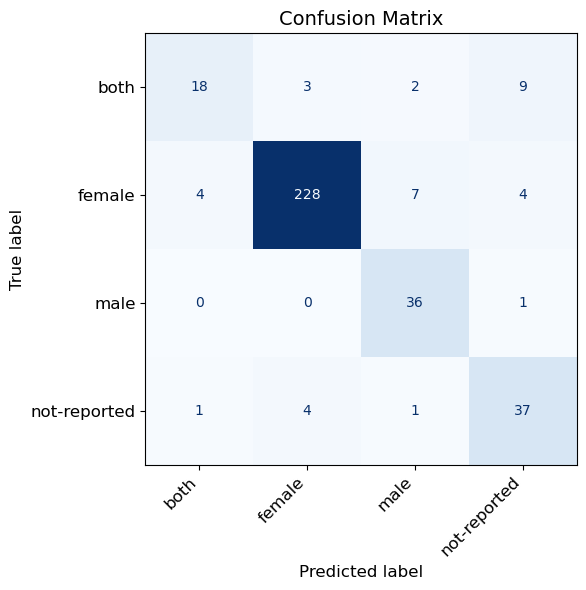

In [74]:
res = eval_categorical(
    df,
    target_col="Sex",
    pred_col="animal_sex",
    id_col="pmid"
)

res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/sex_mismatches.csv")

                        precision    recall  f1-score   support

            cat, mouse      0.000     0.000     0.000         0
              cat, rat      0.000     0.000     0.000         0
       dog, mouse, rat      0.000     0.000     0.000         0
            guinea pig      1.000     1.000     1.000         1
guinea pig, mouse, rat      0.000     0.000     0.000         0
                monkey      1.000     1.000     1.000         2
                 mouse      0.996     0.934     0.964       287
            mouse, rat      0.000     0.000     0.000         0
        mouse, xenopus      0.000     0.000     0.000         1
                   rat      1.000     0.905     0.950        63
         species-other      0.000     0.000     0.000         0
             zebrafish      0.000     0.000     0.000         1

              accuracy                          0.924       355
             macro avg      0.333     0.320     0.326       355
          weighted avg      0.991     

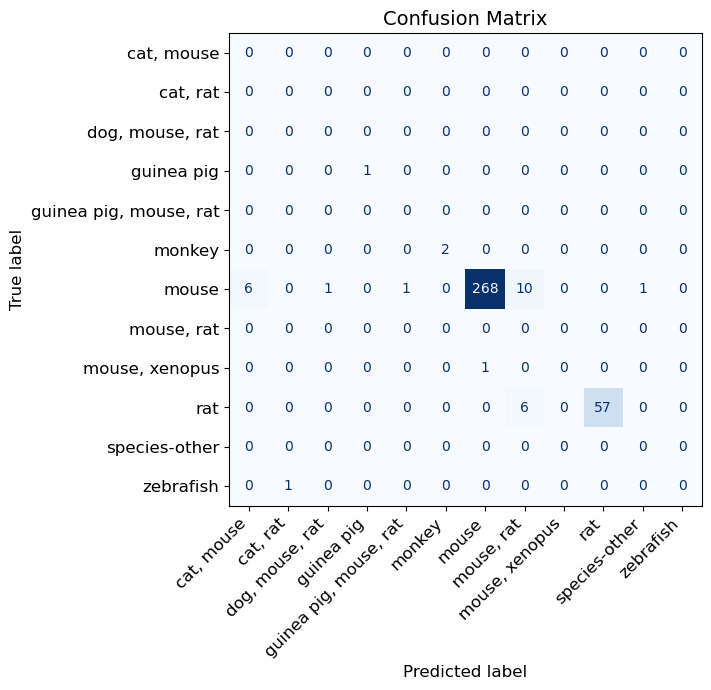

In [75]:
df["Species"] = df["Species"].replace("marmoset", "monkey")

res = eval_categorical(
    df,
    target_col="Species",
    pred_col="animal_species",
    id_col="pmid"
)
res["mismatches"].to_csv("./outputs/ms_hermes_annotations_validation/species_mismatches.csv")

In [76]:
def evaluate_multilabel_sets(
    df: pd.DataFrame,
    true_col: str,
    pred_col: str,
    sep: str = ",",
    class_order: list[str] | None = None,
    show_per_class_report: bool = True,
    plot_per_class_confmat: bool = False,
    extra_cols: list[str] | None = None,   # e.g., ["pmid"]
    id_col: str | None = None              # e.g., "pmid"
):
    # --- helpers ---
    def _normalize(s: str) -> str:
        return s.strip().lower()

    def _split_set(x, sep=","):
        if pd.isna(x):
            return set()
        parts = [p for p in str(x).split(sep)]
        return {_normalize(p) for p in parts if _normalize(p)}

    # Resolve a column or index (case-insensitive); if not found and name == 'pmid',
    # fall back to using the index values and name it 'pmid'.
    colmap = {c.lower(): c for c in df.columns}
    def _get_series(name: str):
        if name is None:
            return None
        # exact column
        if name in df.columns:
            return df[name]
        # case-insensitive column
        low = name.lower()
        if low in colmap:
            return df[colmap[low]]
        # index name match (case-insensitive)
        if df.index.name and df.index.name.lower() == low:
            return pd.Series(df.index, index=df.index, name=df.index.name)
        # final fallback for 'pmid': use index even if unnamed
        if low == "pmid":
            return pd.Series(df.index, index=df.index, name="pmid")
        return None

    # Parse to sets
    y_true_sets = df[true_col].map(lambda x: _split_set(x, sep))
    y_pred_sets = df[pred_col].map(lambda x: _split_set(x, sep))

    # Row-level counts
    n_true = y_true_sets.map(len)
    n_pred = y_pred_sets.map(len)

    # Any-overlap & exact-set match
    any_overlap = pd.Series([(len(t & p) > 0) for t, p in zip(y_true_sets, y_pred_sets)], index=df.index)
    exact_match = pd.Series([(t == p) for t, p in zip(y_true_sets, y_pred_sets)], index=df.index)

    # Label universe
    if class_order is None:
        all_labels = sorted(set().union(*y_true_sets, *y_pred_sets))
    else:
        all_labels = list(class_order)

    # Binarize
    mlb = MultiLabelBinarizer(classes=all_labels)
    Y_true = mlb.fit_transform(y_true_sets)
    Y_pred = mlb.transform(y_pred_sets)

    # Metrics
    subset_acc = accuracy_score(Y_true, Y_pred)
    jaccard_samples = jaccard_score(Y_true, Y_pred, average="samples") if len(df) else 0.0
    prec_micro, rec_micro, f1_micro, _ = precision_recall_fscore_support(Y_true, Y_pred, average="micro", zero_division=0)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(Y_true, Y_pred, average="macro", zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(Y_true, Y_pred, average="weighted", zero_division=0)

    class_report = None
    if show_per_class_report and len(all_labels) > 0:
        class_report = classification_report(Y_true, Y_pred, target_names=all_labels, zero_division=0, digits=3)

    per_class_conf = multilabel_confusion_matrix(Y_true, Y_pred, labels=range(len(all_labels)))

    stats = {
        "total_rows": int(len(df)),
        "any_overlap_accuracy": float(any_overlap.mean()) if len(df) else 0.0,
        "exact_match_accuracy": float(subset_acc),
        "jaccard_samples": float(jaccard_samples),
        "num_multi_pred": int((n_pred > 1).sum()),
        "rate_multi_pred": float((n_pred > 1).mean()) if len(df) else 0.0,
        "num_single_pred": int((n_pred == 1).sum()),
        "num_zero_pred": int((n_pred == 0).sum()),
        "num_multi_true": int((n_true > 1).sum()),
        "rate_multi_true": float((n_true > 1).mean()) if len(df) else 0.0,
        "precision_micro": float(prec_micro),
        "recall_micro": float(rec_micro),
        "f1_micro": float(f1_micro),
        "precision_macro": float(prec_macro),
        "recall_macro": float(rec_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(prec_weighted),
        "recall_weighted": float(rec_weighted),
        "f1_weighted": float(f1_weighted),
        "labels": all_labels,
    }

    # --- per-row overview (include extras + robust id handling) ---
    cols = {
        "true_raw": df[true_col],
        "pred_raw": df[pred_col],
        "true_set": y_true_sets,
        "pred_set": y_pred_sets,
        "n_true": n_true,
        "n_pred": n_pred,
        "any_overlap_correct": any_overlap,
        "exact_match": exact_match,
    }

    # Add extra columns (case-insensitive; column or index; pmid fallback)
    if extra_cols:
        for c in extra_cols:
            s = _get_series(c)
            if s is not None:
                cols[c] = s

    per_row = pd.DataFrame(cols)

    # Ensure id_col exists, then move first and set as index (keeping the column)
    if id_col:
        s = _get_series(id_col)
        if s is not None:
            per_row[id_col] = s
        if id_col in per_row.columns:
            ordered = [id_col] + [c for c in per_row.columns if c != id_col]
            per_row = per_row[ordered].set_index(id_col, drop=False)  # change to drop=True if you only want it as index

    if class_report:
        print(class_report)

    return stats, per_row, per_class_conf

In [77]:
df = ms_hermes_joined.copy()

In [78]:
stats, per_row, per_class = evaluate_multilabel_sets(
    df,
    true_col="Strain",
    pred_col="animal_strain",
    sep=",",
    extra_cols=["pmid"],   # include pmid in the overview
    id_col="pmid"          # show pmid as the index/first column
)

print(stats["any_overlap_accuracy"])
# Peek at rows with mismatches, but include pmid:
per_row[~per_row["any_overlap_correct"]].head()


                           precision    recall  f1-score   support

           (plj/j x sjl)f      0.000     0.000     0.000         1
               (plxsjl)f1      0.000     0.000     0.000         4
           (sjlxbalb/c)f1      0.000     0.000     0.000         4
              (swrxsjl)f1      0.000     0.000     0.000         1
                       1s      0.000     0.000     0.000         0
                       2b      0.000     0.000     0.000         0
                       2d      0.000     0.000     0.000         0
                      2d2      0.000     0.000     0.000         0
                     2d2t      0.000     0.000     0.000         0
                      abc      0.000     0.000     0.000         0
                    agout      0.000     0.000     0.000         0
                   agouti      0.000     0.000     0.000         0
                      b10      0.000     0.000     0.000         0
                   b10.pl      0.000     0.000     0.000     

,pmid,true_raw,pred_raw,true_set,pred_set,n_true,n_pred,any_overlap_correct,exact_match
pmid,,,,,,,,,
23954214,23954214,Dark Agouti,"Agouti,DA",{dark agouti},"{agouti, da}",1,2,False,False
16365293,16365293,"C57BL/6, (SJLxBALB/c)F1","C57Bl,Sj","{(sjlxbalb/c)f1, c57bl/6}","{sj, c57bl}",2,2,False,False
12020957,12020957,(SJLxBALB/c)F1,SjlJ,{(sjlxbalb/c)f1},{sjlj},1,1,False,False
21752599,21752599,(SJLxBALB/c)F1,"C57BL/6,SJL",{(sjlxbalb/c)f1},"{sjl, c57bl/6}",1,2,False,False
21459808,21459808,Biozzi ABH,not reported,{biozzi abh},{not reported},1,1,False,False


In [79]:
def eval_animal_number(
    df,
    true_col="Total number of animals",
    pred_col="animal_number",
    atol=1e-9
):
    """
    Evaluates numeric predictions vs. true totals.
    exact_match = single prediction == true
    partial_match = true in predictions AND more than one prediction
    """
    def parse_preds(val):
        if pd.isna(val):
            return []
        if isinstance(val, (list, tuple, np.ndarray)):
            return [float(v) for v in val if pd.notna(v)]
        if isinstance(val, str):
            try:
                parsed = ast.literal_eval(val)
                if isinstance(parsed, (list, tuple)):
                    return [float(v) for v in parsed]
                else:
                    return [float(parsed)]
            except Exception:
                nums = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', val)
                return [float(n) for n in nums] if nums else []
        try:
            return [float(val)]
        except Exception:
            return []

    rows = []
    for _, r in df.iterrows():
        true_val = float(r[true_col])
        raw_pred = r[pred_col]
        preds = parse_preds(raw_pred)

        best_pred = np.nan
        abs_error = np.nan
        rel_error = np.nan
        exact_match = False
        partial_match = False
        contains_true = any(isclose(p, true_val, abs_tol=atol) for p in preds)

        if preds:
            errors = [abs(p - true_val) for p in preds]
            j = int(np.argmin(errors))
            best_pred = preds[j]
            abs_error = errors[j]
            rel_error = abs_error / true_val if true_val else np.nan

            if contains_true:
                if len(preds) == 1:
                    exact_match = True
                elif len(preds) > 1:
                    partial_match = True

        # others relative to true
        others = [p for p in preds if not isclose(p, true_val, abs_tol=atol)]
        other_preds_below_true = [p for p in others if p < true_val] or None
        other_preds_above_true = [p for p in others if p > true_val] or None

        rows.append({
            "true": true_val,
            "pred_raw": raw_pred,
            "best_pred": best_pred,
            "abs_error": abs_error,
            "rel_error": rel_error,
            "exact_match": exact_match,
            "partial_match": partial_match,
            "other_preds_below_true": other_preds_below_true,
            "other_preds_above_true": other_preds_above_true,
        })

    per_row = pd.DataFrame(rows)

    summary = {
        "n": len(per_row),
        "n_exact_match": int(per_row["exact_match"].sum()),
        "exact_match_rate": per_row["exact_match"].mean(),
        "n_partial_match": int(per_row["partial_match"].sum()),
        "partial_match_rate": per_row["partial_match"].mean(),
        "mean_abs_error": per_row["abs_error"].mean(),
        "median_abs_error": per_row["abs_error"].median(),
        "mean_rel_error": per_row["rel_error"].mean(),
    }

    return summary, per_row

In [80]:
filtered_animal_nr_both_labeled = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] != "not-reported") &
    (ms_hermes_joined["animal_number"] != "unlabeled")
]
summary, details = eval_animal_number(filtered_animal_nr_both_labeled,
                                      true_col="Total number of animals",
                                      pred_col="animal_number")

print(summary)
print(details.head())

{'n': 113, 'n_exact_match': 38, 'exact_match_rate': 0.336283185840708, 'n_partial_match': 7, 'partial_match_rate': 0.061946902654867256, 'mean_abs_error': 2.784313725490196, 'median_abs_error': 0.0, 'mean_rel_error': 0.0491024162304439}
    true      pred_raw  best_pred  abs_error  rel_error  exact_match  \
0  163.0  not reported        NaN        NaN        NaN        False   
1   18.0  not reported        NaN        NaN        NaN        False   
2   85.0          85.0       85.0        0.0        0.0         True   
3   32.0          32.0       32.0        0.0        0.0         True   
4   96.0          96.0       96.0        0.0        0.0         True   

   partial_match other_preds_below_true other_preds_above_true  
0          False                   None                   None  
1          False                   None                   None  
2          False                   None                   None  
3          False                   None                   None  
4    

In [81]:
details.to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions.csv", index=False)

In [82]:
filtered_animal_nr_pred_only = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] == "not-reported") &
    (ms_hermes_joined["animal_number"] != "unlabeled")
]
filtered_animal_nr_pred_only[['PMID','Total number of animals', 'animal_number']]
filtered_animal_nr_pred_only[['PMID','Total number of animals', 'animal_number']].to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions_FP.csv",index=False)

In [83]:
filtered_animal_nr_pred_missing = ms_hermes_joined[
    (ms_hermes_joined["Total number of animals"] != "not-reported") &
    (ms_hermes_joined["animal_number"] == "unlabeled")
]
filtered_animal_nr_pred_missing[['PMID','Total number of animals', 'animal_number']]
filtered_animal_nr_pred_missing[['PMID','Total number of animals', 'animal_number']].to_csv("./outputs/ms_hermes_annotations_validation/animals_nr_predictions_FN.csv",index=False)

### drug

In [84]:
from transformers import AutoTokenizer, AutoModel


In [23]:
ms_hermes_joined_drugs = ms_hermes_joined[['PMID','Tested drug(s)','drug_term_umls_norm']]

In [24]:
CURRENT_DIR = Path().resolve()
NORM_MODULE_PATH = CURRENT_DIR.parent / "04_normalization"
sys.path.insert(0, str(NORM_MODULE_PATH))

from neural_based_nen import map_query_to_terminology

In [25]:
CURRENT_DIR = Path().resolve().parent
NORM_MODULE_PATH = CURRENT_DIR.parent / "04_normalization"
sys.path.insert(0, str(NORM_MODULE_PATH))
from neural_based_nen import map_query_to_terminology

TERMINOLOGY = "umls"
DIST_THRESHOLD = 7.8
EMBEDDINGS_DIR = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/embeddings"
BATCH_PREFIX = "UMLS_emb"
TERM_ID_FILE = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/umls_term_id_pairs.json"
ID_TO_TERM_MAP = f"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/{TERMINOLOGY}/{TERMINOLOGY}_id_to_term_map.json"

# --- Load embeddings ---
embedding_files = sorted([
    os.path.join(EMBEDDINGS_DIR, f) for f in os.listdir(EMBEDDINGS_DIR)
    if f.startswith(f"{BATCH_PREFIX}_batch_") and f.endswith(".npy")
])
all_embeddings = [np.load(f) for f in embedding_files]
embeddings_to_use = np.concatenate(all_embeddings, axis=0)

# --- Load mapping and metadata ---
with open(TERM_ID_FILE, "r") as f:
    corresponding_term_id = json.load(f)

with open(ID_TO_TERM_MAP, "r", encoding="utf-8") as f:
    canonical_mapping_dict = json.load(f)

# --- Load model ---
tokenizer = AutoTokenizer.from_pretrained("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")
model = AutoModel.from_pretrained("cambridgeltl/SapBERT-from-PubMedBERT-fulltext")



/home/sdonev/.local/lib/python3.11/site-packages/huggingface_hub/file_download.py:896: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [26]:
def normalize_tested_drugs_cell(
    cell: str,
    tokenizer,
    model,
    embeddings_to_use,
    corresponding_term_id,
    canonical_mapping_dict,
    dist_threshold: float
) -> str:
    """
    Normalize a comma-separated string of drugs into a '|' separated string of canonical names.
    - Keeps original term when map_query_to_terminology returns -1 (your function already does that).
    - Deduplicates while preserving order.
    - Handles NaN / empty cells gracefully.
    """
    if pd.isna(cell) or not isinstance(cell, str):
        return ""

    # Split by commas (tolerate extra spaces); ignore empty chunks
    parts = [p.strip() for p in re.split(r"\s*,\s*", cell) if p.strip()]
    if not parts:
        return ""

    canonicals = []
    seen = set()
    for query in parts:
        predicted_id, predicted_label, canonical_form, nearest_3, nn_dist = map_query_to_terminology(
            query,
            tokenizer,
            model,
            embeddings_to_use,
            corresponding_term_id,
            canonical_mapping_dict,
            dist_threshold=dist_threshold
        )
        # Use canonical_form (your function already falls back to original query if no mapping)
        if canonical_form not in seen:
            seen.add(canonical_form)
            canonicals.append(canonical_form)

    # Join canonicals with pipe
    return "|".join(canonicals)



In [27]:
ms_hermes_joined_drugs

,PMID,Tested drug(s),drug_term_umls_norm
2,30185466,Minocycline,mac1-saporin|Minocycline
4,23954214,Vitamin D3,VITAMIN D|Ergocalciferol
5,31715458,Interferon Beta 1,beta Interferon|Interferon beta (recombinant)
6,16148229,Glatiramer acetate,"Acetate, Glatiramer"
7,16365293,Glatiramer acetate,"Acetate, Glatiramer|ga"
...,...,...,...
457,29266540,Fingolimod,Fingolimod
458,29085356,Vitamin D3,Paricalcitol|Vitamin D analog|Vitamin D analog
459,31523122,Dimethyl fumarate,"Fumarate, Dimethyl"
460,24045165,Cladribine,Cladribine


In [31]:
# Apply to your DataFrame
# Assumes you already have: tokenizer, model, embeddings_to_use, corresponding_term_id, canonical_mapping_dict, DIST_THRESHOLD
ms_hermes_joined_drugs["unique_drug_target"] = ms_hermes_joined_drugs["Tested drug(s)"].progress_apply(
    lambda cell: normalize_tested_drugs_cell(
        cell,
        tokenizer,
        model,
        embeddings_to_use,
        corresponding_term_id,
        canonical_mapping_dict,
        dist_threshold=DIST_THRESHOLD
    )
)

100%|██████████| 355/355 [02:25<00:00,  2.43it/s]
/sctmp/sdonev/ipykernel_1005517/2574029870.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hermes_joined_drugs["unique_drug_target"] = ms_hermes_joined_drugs["Tested drug(s)"].progress_apply(


In [32]:
ms_hermes_joined_drugs

,PMID,Tested drug(s),drug_term_umls_norm,Target_drug_norm,unique_drug_target
2,30185466,Minocycline,mac1-saporin|Minocycline,Minocycline,Minocycline
4,23954214,Vitamin D3,VITAMIN D|Ergocalciferol,vitamin D3,vitamin D3
5,31715458,Interferon Beta 1,beta Interferon|Interferon beta (recombinant),beta 1 Interferon,beta 1 Interferon
6,16148229,Glatiramer acetate,"Acetate, Glatiramer","Acetate, Glatiramer","Acetate, Glatiramer"
7,16365293,Glatiramer acetate,"Acetate, Glatiramer|ga","Acetate, Glatiramer","Acetate, Glatiramer"
...,...,...,...,...,...
457,29266540,Fingolimod,Fingolimod,Fingolimod,Fingolimod
458,29085356,Vitamin D3,Paricalcitol|Vitamin D analog|Vitamin D analog,vitamin D3,vitamin D3
459,31523122,Dimethyl fumarate,"Fumarate, Dimethyl","Fumarate, Dimethyl","Fumarate, Dimethyl"
460,24045165,Cladribine,Cladribine,Cladribine,Cladribine


In [36]:
def compute_annotations(row, entity, model):

    target_col = f'unique_{entity.replace("_v1","").replace("_v2","")}_target'
    model_col = "drug_term_umls_norm"#f'unique_{entity}_{model}'
    
    target_entities = (
        [] if pd.isna(row[target_col]) or str(row[target_col]).strip() == ""
        else str(row[target_col]).split('|')
    )
    # IGNORE ABBREVIATIONS
    target_entities = [e for e in target_entities if len(e) > 2]

    predicted_entities = (
        [] if pd.isna(row[model_col]) or str(row[model_col]).strip() == ""
        else str(row[model_col]).split('|')
    )
    # IGNORE ABBREVIATIONS
    predicted_entities = [e for e in predicted_entities if len(e) > 2]

    if not target_entities or not predicted_entities:
        return handle_empty_arrays(target_entities, predicted_entities)

    # Create a set of all unique entities from both target and predicted for consistent indexing
    all_entities = set(target_entities + predicted_entities)

    # Target annotations (exact)
    target_annotations_exact = [1 if entity in target_entities else 0 for entity in all_entities]

    # Predicted annotations (exact)
    predicted_annotations_exact = [1 if entity in predicted_entities else 0 for entity in all_entities]

    # Target annotations (partial)
    target_annotations_partial = [1 if any(partial_match(entity, target_ent) for target_ent in target_entities) else 0 for entity in all_entities]

    # Predicted annotations (partial)
    predicted_annotations_partial = [1 if any(partial_match(entity, pred) for pred in predicted_entities) else 0 for entity in all_entities]

    return pd.Series([
        target_annotations_exact,
        predicted_annotations_exact,
        target_annotations_partial,
        predicted_annotations_partial
    ], index=[
        f'target_{entity}_annotations_exact_{model}',
        f'predicted_{entity}_annotations_exact_{model}',
        f'target_{entity}_annotations_partial_{model}',
        f'predicted_{entity}_annotations_partial_{model}'
    ])

In [39]:
def partial_match_simple(predicted, target):
    predicted_parts = predicted.lower().split()
    target_parts = target.lower().split()
    return any(pred_part in target_part or target_part in pred_part for pred_part in predicted_parts for target_part in target_parts)

# Function to check for partial matches using difflib
def partial_match(predicted, target, cutoff=0.6):
    # Split the conditions into individual terms
    predicted_terms = predicted.split('|')
    target_terms = target.split('|')
    
    # Check for matches across all terms
    matches = []
    for pred in predicted_terms:
        # Use difflib to find close matches, with a cutoff for match quality
        match_found = any(difflib.get_close_matches(pred, target_terms, n=1, cutoff=cutoff))
        matches.append(match_found)
    
    # Return True if any match is found
    return any(matches)

def handle_empty_arrays(target_entities, predicted_entities):
    # Construct the results based on whether target_entities or predicted_entities are empty
    if target_entities == [''] and predicted_entities == ['']:
        return pd.Series([
            [0],  # No target entities to match against, so exact match is [0]
            [0],  # No predicted entities to match against, so exact match is [0]
            [0],  # No target entities for partial matches, so partial match is [0]
            [0]   # No predicted entities for partial matches, so partial match is [0]
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    elif target_entities == ['']:
        return pd.Series([
            [0] * len(predicted_entities),  
            [1] * len(predicted_entities),  
            [0] * len(predicted_entities), 
            [1] * len(predicted_entities)  
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
    # Handle case where predicted_entities is empty, if required
    else: # predicted_entities == ['']:
        return pd.Series([
            [1] * len(target_entities), 
            [0] * len(target_entities),  
            [1] * len(target_entities),  
            [0] * len(target_entities)   
        ], index=[
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ])
        
def flatten_column_arrays(column):
    # Prepare an array to hold the actual arrays/lists
    prepared_arrays = []
    
    for item in column:
        if isinstance(item, str):
            try:
                # Safely evaluate the string to see if it represents a list
                evaluated_item = ast.literal_eval(item)
                if isinstance(evaluated_item, list):
                    prepared_arrays.append(np.array(evaluated_item))
            except (SyntaxError, ValueError):
                # If evaluation fails or it's not a list, skip or handle non-list string
                print("Not possible to flatten ", item)
                continue
        elif isinstance(item, list):
            prepared_arrays.append(np.array(item))
        elif isinstance(item, np.ndarray):
            prepared_test_arrays.append(item)
    
    if prepared_arrays:
        # Concatenate all arrays in the list and then flatten the result
        return np.concatenate(prepared_arrays).flatten()
    else:
        return np.array([])  # Return an empty array if no valid arrays were found

def round_tuple(x, decimals=2):
    """
    Recursively round elements of a tuple.
    If x is a scalar (int/float), return the rounded value directly.
    """
    if isinstance(x, (int, float)):
        return round(x, decimals)
    elif isinstance(x, tuple):
        return tuple(round_tuple(item, decimals) for item in x)
    else:
        raise TypeError(f"Unsupported type {type(x)} for round_tuple")
        
def calculate_exact_and_partial_match_scores(annotations_df, entities, models, round_to=2):
    exact_matches = {}
    partial_matches = {}
    scores = {}
    for entity in entities:
        exact_matches[entity] = {}
        partial_matches[entity] = {}
        scores[entity] = {}
    
        for model in models:
            if (entity != 'condition' and entity != 'drug') and 'regex' in model:
               continue  
            #try:
            # Check if all columns are present in the DataFrame
            # Columns to check
            columns_to_check = [f'target_{entity}_annotations_exact_{model}',
                                f'predicted_{entity}_annotations_exact_{model}',
                                f'target_{entity}_annotations_partial_{model}',
                                f'predicted_{entity}_annotations_partial_{model}']
            
            # Check if all columns are present in the DataFrame
            missing_columns = [col for col in columns_to_check if col not in annotations_df.columns]
            if not missing_columns:
                flattened_data_target_exact = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_exact_{model}'])
                flattened_data_model_exact = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_exact_{model}'])
                flattened_data_target_partial = flatten_column_arrays(annotations_df[f'target_{entity}_annotations_partial_{model}'])
                flattened_data_model_partial = flatten_column_arrays(annotations_df[f'predicted_{entity}_annotations_partial_{model}'])
            else:
                # Handle the case where one or more columns are missing
                print("The following required columns are missing in the DataFrame:")
                for col in missing_columns:
                    print(col)
    
            flattened_data_target_exact = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_model_exact = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_exact_{model}', pd.Series()))
            flattened_data_target_partial = flatten_column_arrays(annotations_df.get(f'target_{entity}_annotations_partial_{model}', pd.Series()))
            flattened_data_model_partial = flatten_column_arrays(annotations_df.get(f'predicted_{entity}_annotations_partial_{model}', pd.Series()))

            # Calculate and store F1 scores
            exact_f1 = f1_score(flattened_data_target_exact, flattened_data_model_exact, average='binary')
            print(exact_f1)
            partial_f1 = f1_score(flattened_data_target_partial, flattened_data_model_partial, average='binary')

            exact_precision = precision_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_precision = precision_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_recall = recall_score(flattened_data_target_exact, flattened_data_model_exact)
            partial_recall = recall_score(flattened_data_target_partial, flattened_data_model_partial)

            exact_matches[entity][model] = round_tuple(exact_f1,round_to)
            partial_matches[entity][model] = round_tuple(partial_f1,round_to)

            scores[entity][model] = {
                "exact": {
                    "precision": round_tuple(exact_precision, round_to),
                    "recall": round_tuple(exact_recall, round_to),
                    "f1": round_tuple(exact_f1, round_to),
                },
                "partial": {
                    "precision": round_tuple(partial_precision, round_to),
                    "recall": round_tuple(partial_recall, round_to),
                    "f1": round_tuple(partial_f1, round_to),
                }
            }
    
           # except Exception as e:
            #    print(f"An error occurred for {model} in {entity}: {e}")
    return exact_matches, partial_matches, scores

In [42]:
entity = "drug"
model = "biolinkbert"
annotations_cols = [
            f'target_{entity}_annotations_exact_{model}',
            f'predicted_{entity}_annotations_exact_{model}',
            f'target_{entity}_annotations_partial_{model}',
            f'predicted_{entity}_annotations_partial_{model}'
        ]
ms_hermes_joined_drugs[annotations_cols] = ms_hermes_joined_drugs.apply(lambda row: compute_annotations(row, entity, model), axis=1)

/sctmp/sdonev/ipykernel_1005517/1897134427.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hermes_joined_drugs[annotations_cols] = ms_hermes_joined_drugs.apply(lambda row: compute_annotations(row, entity, model), axis=1)
/sctmp/sdonev/ipykernel_1005517/1897134427.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ms_hermes_joined_drugs[annotations_cols] = ms_hermes_joined_drugs.apply(lambda row: compute_annotations(row, entity, model), axis=1)
/sctmp/sdonev/ipykernel_1005517/1897134427.py:9: Setting

In [43]:
models = ['biolinkbert']


In [52]:
ms_hermes_joined_drugs[ms_hermes_joined_drugs["target_drug_annotations_partial_biolinkbert"]!=ms_hermes_joined_drugs["predicted_drug_annotations_partial_biolinkbert"]].to_csv("./outputs/ms_hermes_annotations_validation/drug_discrepancies.csv",index=False)

In [47]:
exact_matches, partial_matches, scores = calculate_exact_and_partial_match_scores(ms_hermes_joined_drugs, ["drug"], models)


0.33256351039260973


In [48]:
scores

{'drug': {'biolinkbert': {'exact': {'precision': 0.23,
    'recall': 0.61,
    'f1': 0.33},
   'partial': {'precision': 0.37, 'recall': 0.82, 'f1': 0.51}}}}

## disease

In [85]:
ms_hermes_joined_disease = ms_hermes_joined[["PMID","disease_term_mondo_norm", "title_x"]]

In [86]:
ms_hermes_joined_disease.head()

,PMID,disease_term_mondo_norm,title_x
2,30185466,multiple sclerosis,Reduced Microglial Activity and Enhanced Gluta...
4,23954214,multiple sclerosis|myeloid sarcoma,Efficacy of vitamin D in treating multiple scl...
5,31715458,multiple sclerosis,B cell function impacts the efficacy of IFN-Î²...
6,16148229,multiple sclerosis,Neurogenesis and neuroprotection induced by pe...
7,16365293,multiple sclerosis,The immunomodulator glatiramer acetate augment...


In [87]:
mask = ~ms_hermes_joined_disease["disease_term_mondo_norm"].str.contains("multiple sclerosis", case=False, na=False)
df_no_ms = ms_hermes_joined_disease[mask]
df_no_ms

,PMID,disease_term_mondo_norm,title_x
31,15378653,spinal cord injury|demyelinating disease,K+ channel blockade impairs remyelination in t...
371,20544279,Balo concentric sclerosis|demyelinating disease,Beneficial effects of minocycline on cuprizone...


In [88]:
df_no_ms.shape

(2, 3)